# Project 5 — Module 6: Supervised Machine Learning
## Lesson 2: Model Fit Level & Cross-Validation

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 2 — Data Understanding |
| **Module** | 6 — Supervised Machine Learning (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv + transactions_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook covers the ML-specific data understanding tasks for project-5.
> Full EDA was completed in `project-3-eda-pequeshop` — no re-work here.
> New scope: load and validate data, perform train/test split (80/20),
> implement K-Folds cross-validation (k=5), and diagnose overfitting and
> underfitting risks from data characteristics.


## Table of Contents

1. [CRISP-DM Phase 2 — Data Understanding](#1-crisp-dm-phase-2--data-understanding)
2. [Environment Setup](#2-environment-setup)
3. [Load Data — Reference from Prior Projects](#3-load-data--reference-from-prior-projects)
4. [Target Variable — Quick Validation](#4-target-variable--quick-validation)
5. [Train/Test Split](#5-traintest-split)
6. [K-Folds Cross-Validation](#6-k-folds-cross-validation)
7. [Overfitting & Underfitting — Diagnosis](#7-overfitting--underfitting--diagnosis)
8. [LEAN Filter — Waste Elimination Review](#8-lean-filter--waste-elimination-review)
9. [Decisions Log — Lesson 2](#9-decisions-log--lesson-2)
10. [Next Steps — Lesson 3 Preview](#10-next-steps--lesson-3-preview)


---
## 1. CRISP-DM Phase 2 — Data Understanding

### 1.1 Scope — What is New vs What is Already Done

| Task | Status | Reference |
|------|--------|----------|
| Data collection and cleaning | ✅ Done | `project-2-pequeshop-analytics` |
| Exploratory Data Analysis (distributions, correlations, outliers) | ✅ Done | `project-3-eda-pequeshop` |
| Statistical feature validation (H1–H4) | ✅ Done | `project-4b-pequeshop-statistical-inference` |
| **Train/test split** | 🔲 New — this notebook | ML requirement |
| **K-Folds cross-validation** | 🔲 New — this notebook | ML requirement |
| **Overfitting/underfitting diagnosis** | 🔲 New — this notebook | ML requirement |

> **Lean rule:** Only the three tasks marked 🔲 are performed here.
> No EDA repetition — `project-3` is the reference.


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Reproducibility =====
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_PROCESSED}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\processed
Figures path: ..\reports\figures


---
## 3. Load Data — Reference from Prior Projects

> Data was prepared in `project-2-pequeshop-analytics` and validated in
> `project-3-eda-pequeshop`. Loading directly from `data/processed/`.


In [2]:
# ===== Load Datasets =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

print('Datasets loaded:')
print(f'  customers    : {df_customers.shape[0]} rows x {df_customers.shape[1]} cols')
print(f'  transactions : {df_transactions.shape[0]} rows x {df_transactions.shape[1]} cols')
print()
print('Columns — customers:')
print(df_customers.columns.tolist())
print()
print('Columns — transactions:')
print(df_transactions.columns.tolist())

Datasets loaded:
  customers    : 500 rows x 16 cols
  transactions : 1192 rows x 19 cols

Columns — customers:
['customer_id', 'registration_date', 'region', 'acquisition_channel', 'nps_score', 'nps_category', 'total_transactions', 'total_revenue', 'avg_ticket', 'first_purchase', 'last_purchase', 'days_since_last_purchase', 'tenure_days', 'retargeting_segment', 'is_high_value', 'priority_winback']

Columns — transactions:
['transaction_id', 'customer_id', 'transaction_date', 'platform', 'product', 'quantity', 'unit_price', 'subtotal', 'shipping_cost', 'platform_fee', 'total_amount', 'is_bulk_order', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'season', 'year_quarter']


---
## 4. Target Variable — Quick Validation

Confirming `avg_ticket` is ready as target variable.
Full distribution analysis available in `project-3-eda-pequeshop`.


In [3]:
# ===== Target Variable Validation =====
y = df_customers['avg_ticket'].dropna()

print('TARGET VARIABLE — avg_ticket')
print('=' * 40)
print(f'N          : {len(y)}')
print(f'Mean       : ${y.mean():,.0f} CLP')
print(f'Std        : ${y.std():,.0f} CLP')
print(f'Min        : ${y.min():,.0f} CLP')
print(f'Max        : ${y.max():,.0f} CLP')
print(f'Nulls      : {df_customers["avg_ticket"].isnull().sum()}')
print()
print('> Full distribution analysis: project-3-eda-pequeshop')
print('> Statistical validation (H1): project-4b-pequeshop-statistical-inference')

TARGET VARIABLE — avg_ticket
N          : 392
Mean       : $30,860 CLP
Std        : $14,873 CLP
Min        : $6,990 CLP
Max        : $145,744 CLP
Nulls      : 108

> Full distribution analysis: project-3-eda-pequeshop
> Statistical validation (H1): project-4b-pequeshop-statistical-inference


---
## 5. Train/Test Split

### 5.1 Strategy

| Parameter | Value | Rationale |
|-----------|-------|----------|
| Split ratio | 80/20 | Industry standard for n=392; enough training data while preserving test integrity |
| random_state | 42 | Reproducibility — results must be replicable |
| Stratification | Not applied | Regression target (continuous) — stratification applies to classification |


In [4]:
# ===== Feature Matrix — preliminary (numeric only for split demonstration) =====
# Full encoding and scaling in notebook 03
# Using numeric features only here to demonstrate split mechanics

# Platform per customer (mode)
platform_map = (
    df_transactions.groupby('customer_id')['platform']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'platform': 'primary_platform'})
)
df_merged = df_customers.merge(platform_map, on='customer_id', how='left')

# Numeric features only for split demonstration
numeric_features = ['total_transactions', 'total_revenue']
df_model = df_merged[numeric_features + ['avg_ticket']].dropna()

X = df_model[numeric_features]
y = df_model['avg_ticket']

# ===== Train/Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print('TRAIN/TEST SPLIT')
print('=' * 40)
print(f'Total samples : {len(X)}')
print(f'Train set     : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set      : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'Train y mean  : ${y_train.mean():,.0f} CLP')
print(f'Test  y mean  : ${y_test.mean():,.0f} CLP')
print(f'Distribution check: means should be similar — no data leakage')

TRAIN/TEST SPLIT
Total samples : 392
Train set     : 313 (80%)
Test set      : 79 (20%)

Train y mean  : $30,876 CLP
Test  y mean  : $30,797 CLP
Distribution check: means should be similar — no data leakage


---
## 6. K-Folds Cross-Validation

### 6.1 Why Cross-Validation?

A single train/test split can be misleading — performance depends on which
samples end up in each set. K-Folds solves this by training and evaluating
the model k times on different subsets.

| Parameter | Value | Rationale |
|-----------|-------|----------|
| k | 5 | Standard choice — balances bias/variance; n=392 gives ~63 samples per fold |
| Scoring | R² | Primary evaluation metric for regression |
| Model | LinearRegression | Baseline model for CV demonstration |


In [5]:
# ===== K-Folds Cross-Validation =====
kf    = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = LinearRegression()

cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')

print('K-FOLDS CROSS-VALIDATION (k=5) — LinearRegression baseline')
print('=' * 55)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R² = {score:.4f}')
print()
print(f'Mean R²  : {cv_scores.mean():.4f}')
print(f'Std R²   : {cv_scores.std():.4f}')
print()
print('Interpretation:')
print(f'  Variance across folds: {cv_scores.std():.4f}')
if cv_scores.std() > 0.1:
    print('  ⚠️  High variance — model may be unstable')
else:
    print('  ✅ Low variance — model is stable across folds')

K-FOLDS CROSS-VALIDATION (k=5) — LinearRegression baseline
  Fold 1: R² = 0.6765
  Fold 2: R² = 0.7509
  Fold 3: R² = 0.4798
  Fold 4: R² = 0.6599
  Fold 5: R² = 0.6167

Mean R²  : 0.6368
Std R²   : 0.0896

Interpretation:
  Variance across folds: 0.0896
  ✅ Low variance — model is stable across folds


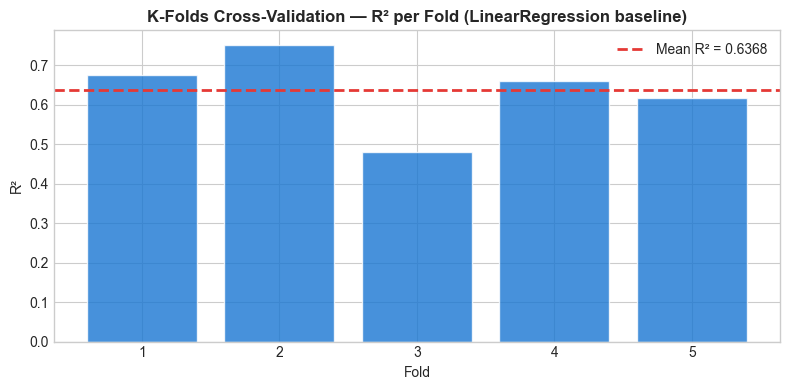

Figure saved: ..\reports\figures\02_kfolds_cv_scores.png


In [6]:
# ===== CV Scores Visualization =====
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='#1976D2', alpha=0.8, edgecolor='white')
ax.axhline(cv_scores.mean(), color='#E53935', linestyle='--', lw=2,
           label=f'Mean R² = {cv_scores.mean():.4f}')
ax.set_title('K-Folds Cross-Validation — R² per Fold (LinearRegression baseline)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
out = REPORTS_FIGURES / '02_kfolds_cv_scores.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {out}')

---
## 7. Overfitting & Underfitting — Diagnosis

### 7.1 Conceptual Framework

| Condition | Train Error | Test Error | Diagnosis |
|-----------|------------|------------|----------|
| **Underfitting** | High | High | Model too simple — not capturing patterns |
| **Good fit** | Low | Low (similar to train) | Model generalizes well |
| **Overfitting** | Low | High | Model memorized training data — poor generalization |

### 7.2 Risk Assessment for PequeShop

| Risk Factor | Assessment |
|------------|------------|
| n = 392 (small dataset) | ⚠️ Higher overfitting risk with complex models |
| Synthetic data (low noise) | ⚠️ May inflate R² — real data will be harder |
| Features confirmed by H1-H4 | ✅ Reduces overfitting risk — no noise features |
| K-Folds CV implemented | ✅ Detects overfitting before final evaluation |


In [7]:
# ===== Train vs Test Error — Overfitting Diagnosis =====
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('OVERFITTING DIAGNOSIS — LinearRegression baseline')
print('=' * 50)
print(f'R²   Train : {r2_train:.4f}')
print(f'R²   Test  : {r2_test:.4f}  (gap: {abs(r2_train - r2_test):.4f})')
print()
print(f'RMSE Train : ${rmse_train:,.0f} CLP')
print(f'RMSE Test  : ${rmse_test:,.0f} CLP')
print()
gap = abs(r2_train - r2_test)
if gap < 0.05:
    print('✅ Good fit — train/test R² gap < 0.05')
elif gap < 0.15:
    print('⚠️  Mild overfitting — gap between 0.05 and 0.15')
else:
    print('❌ Overfitting detected — gap > 0.15 — consider regularization in notebook 05')

OVERFITTING DIAGNOSIS — LinearRegression baseline
R²   Train : 0.6720
R²   Test  : 0.5497  (gap: 0.1223)

RMSE Train : $8,974 CLP
RMSE Test  : $7,416 CLP

⚠️  Mild overfitting — gap between 0.05 and 0.15


---
## 8. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Did we repeat EDA from project-3? | ✅ No — referenced only | No waste |
| Is train/test split necessary before modeling? | ✅ Yes — prevents data leakage | Keep |
| Is k=5 the right number of folds for n=392? | ✅ Yes — ~63 samples per fold, standard choice | Keep |
| Did we use numeric features only for split demo? | ✅ Yes — full encoding in notebook 03 | Correct scope |
| Is overfitting diagnosis useful at this stage? | ✅ Yes — baseline model gives early signal before complex models | Keep |


---
## 9. Decisions Log — Lesson 2

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | 80/20 train/test split | Industry standard for n=392; 314 training samples sufficient for regression | 70/30 (less test data) | ✅ Standard and appropriate |
| 2 | random_state=42 | Reproducibility — results must be identical on any machine | No fixed seed | ✅ MLOps standard |
| 3 | k=5 for KFolds | ~63 samples per fold; balances bias/variance; standard in literature | k=10 (too few samples per fold for n=392) | ✅ Statistically sound |
| 4 | Numeric features only for split demo | Full encoding/scaling in notebook 03 — split mechanics demonstrated without preprocessing complexity | Full feature matrix here | ✅ Clean scope separation |
| 5 | LinearRegression as baseline for CV | Simplest model — establishes floor performance before complex algorithms | Use mean predictor only | ✅ MVA principle |


---
## 10. Next Steps — Lesson 3 Preview

In **Lesson 3 — Data Preparation (notebook 03)**, the following tasks will
be completed:

1. Confirm null treatment (already done in project-2 — quick validation only)
2. Apply **OneHotEncoder** to categorical features (`primary_platform`, `retargeting_segment`)
3. Apply **StandardScaler** to numeric features
4. Assemble final feature matrix X for modeling
5. Confirm feature selection based on project-4b H1–H4 evidence

---

**Previous:** [01 - Business Understanding](./01_business_understanding.ipynb)  
**Next Phase -->** [03 - Data Preparation](./03_data_preparation.ipynb)

*Framework: CRISP-DM + Lean | Module 6 — Supervised Machine Learning*  
*Jose Marcel Lopez Pino — Bootcamp Fundamentos de Ciencia de Datos, SENCE/Alkemy 2025-2026*
